<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Necessary Libraries

In [35]:
#@title Importing necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Part 1: Data Loading and Exploration

In [36]:
#@title Importing and Exploration

# Loading the breast cancer dataset
data = load_breast_cancer()

# Displaying the description and feature names
print("\nDataset Description:")
print(data.DESCR)
print("\nFeature Names:")
print(data.feature_names)

# Creating a DataFrame with the features and target
bc_df = pd.DataFrame(data.data, columns=data.feature_names)
bc_df['target'] = data.target
print("\n=-- DataFrame Information ---")

# Displaying basic statistics
print("\nDataFrame Shape:", bc_df.shape)
print("\nDataFrame Info:")
bc_df.info()
print("\nDataFrame Description:")
print(bc_df.describe())

# Checking for missing values
print("\nMissing Values:")
print(bc_df.isnull().sum())

# Brief observations about the data
print("\n--- Observations ---")
print("The dataset contains 569 samples and 30 features, plus a target variable.There are no missing values in the dataset.")
print("All features appear to be numerical (float64 type). The target variable has two classes, likely representing benign and malignant tumors, as indicated by the original dataset description.")


Dataset Description:
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is

# Part 2: Data Preparation

In [37]:
#@title Splitting the data
X = bc_df.drop('target', axis=1)  # Features
y = bc_df['target']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Successfully split the data")

Successfully split the data


# Part 3: Model Training and Prediction

In [38]:
#@title Model Training Initialization
model = LogisticRegression(random_state=42, max_iter=200) # Increased max_iter to ensure convergence
model.fit(X_train, y_train)

# Making predictions on the test data
y_pred = model.predict(X_test)

print("Logistic Regression model trained and predictions generated.")

Logistic Regression model trained and predictions generated.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Part 4: Model Evaluation

Confusion Matrix:
[[39  4]
 [ 1 70]]


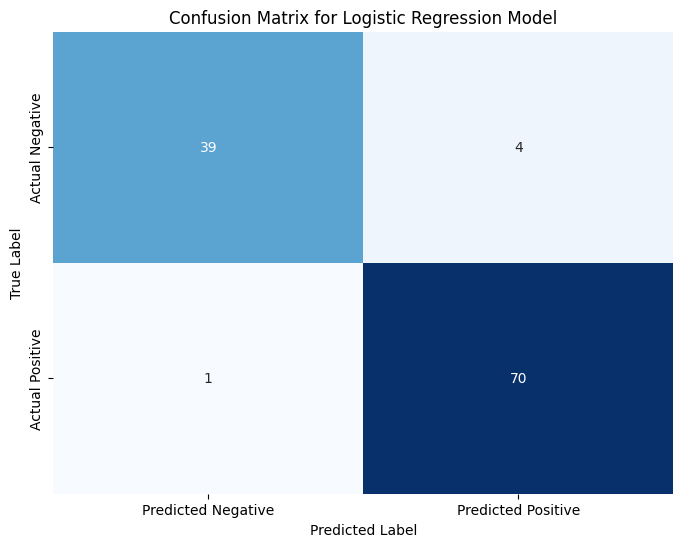

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [39]:
#@title Creating the confusion matrix

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

# Visualizing the confusion matrix for better understanding
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Part 5: Confusion Matrix Analysis

## Confusion Matrix Analysis

Q1) What do the four values in the confusion matrix represent?
--> True Negatives: 39 (correctly predicted negative class)
--> False Positives: 4 (incorrectly predicted as positive when actually negative)
--> False Negatives: 1 (incorrectly predicted as negative when actually positive)
--> True Negatives: 70 (correctly predicted positive class)

Q2) How many cases did the model predict correctly?
--> 109 (39 TN, 70 TP)

Q3) How many cases did the model predict incorrectly?
--> 5 (4 FP, 1 FN)

Q4) Which type of error is more critical in cancer diagnosis (False Negative or False Positive)? Why?
--> A False Negative indicates that the patient doesn't have cancer when they actually do. This is more dangerous because the treatment is delayed (or absent), early detection opportunities are lost, and the tumor can spread. This is life-threatening.
--> A False Postive while still harmful is better because it leads to additional testing and further diagnosis will reveal the truth. This is not life-threatening.
--> Hence, in this dataset False Negatives are more critical than False Positive.

Q4) What does the accuracy score tell you?
--> Accuracy tells you the overall proportion of correct predictions out of all predictions made.
--> Here, in this scenario it is: (39 + 70) / 114 = 95.6% accuracy

Q5) What does precision mean in this context?
--> Of all the cases predicted as cancer, how many actually had cancer?
--> Here, in this scenario it is: 70 / (70 + 4) = 94.6% precision

Q6) What does recall mean in this context?
--> Of all the actual cancer cases, how many did the model catch?
--> Here, in this scenario it is: 70 / (70 + 1) = 98.6% recall

Q7) Why might you care more about recall than precision in medical diagnosis?
--> Missing a cancer case can be dangerous (and/or fatal)
--> False Positives can be corrected
--> Cost of missing a disease is higher than additional diagnosis